# kc11 & mc Histogramme für Overleaf-Paper

Liest `data/Kc11_mc.xlsx` ein, plottet die Rohdaten-Histogramme von `kc11` (Spalte `KC 1.1 [Mpas]`) und `mc` (Spalte `MC`) und legt jeweils eine gefittete Gauß- bzw. Beta-Verteilung darüber. Die kombinierte Abbildung wird als PNG gespeichert.

In [1]:
import os
import sys
sys.path.append("../py/src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from kienzle_utils import MillingSignalUtils as MSU

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.size": 12,
})

In [2]:
df = pd.read_excel("../data/Kc11_mc.xlsx")

# 'kc11'/'mc' columns in the sheet only hold 2 mean/std helper rows (and contain a
# unit mix-up between MPa/kpsi) - use the full per-material raw columns instead.
kc11_data = df["KC 1.1 [Mpas]"].dropna().to_numpy()
mc_data = df["MC"].dropna().to_numpy()

print(f"kc11: n={len(kc11_data)}, mean={kc11_data.mean():.2f}, std={kc11_data.std():.2f}")
print(f"mc:   n={len(mc_data)}, mean={mc_data.mean():.4f}, std={mc_data.std():.4f}")

kc11: n=714, mean=2304.24, std=977.50
mc:   n=714, mean=0.2323, std=0.0198


In [3]:
# Gaussian fit for kc11
mu_kc11, sigma_kc11 = stats.norm.fit(kc11_data)

# Beta fit for mc via moment matching (same convention as the Beta prior in
# kienzle_model_documentation.md, computed with the project's own utility)
alpha_mc, beta_mc = MSU.beta_dist_param(mean=mc_data.mean(), var=mc_data.var())

print(f"kc11 ~ N(mu={mu_kc11:.2f}, sigma={sigma_kc11:.2f})")
print(f"mc   ~ Beta(alpha={alpha_mc:.2f}, beta={beta_mc:.2f})")

kc11 ~ N(mu=2304.24, sigma=977.50)
mc   ~ Beta(alpha=105.64, beta=349.18)


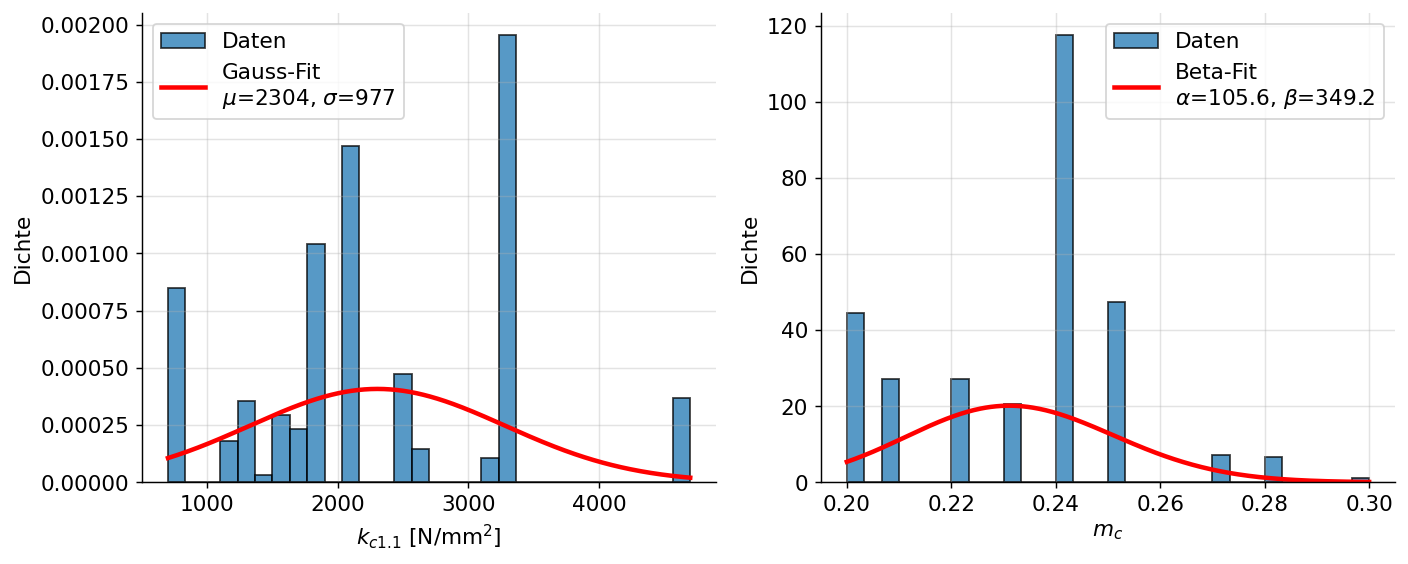

In [4]:
os.makedirs("results", exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# --- kc11: histogram + Gaussian fit ---
ax1.hist(kc11_data, bins=30, density=True, color="#1f77b4",
         edgecolor="black", alpha=0.75, label="Daten")
x1 = np.linspace(kc11_data.min(), kc11_data.max(), 400)
ax1.plot(x1, stats.norm.pdf(x1, mu_kc11, sigma_kc11), color="red", linewidth=2.5,
         label=f"Gauss-Fit\n$\\mu$={mu_kc11:.0f}, $\\sigma$={sigma_kc11:.0f}")
ax1.set_xlabel(r"$k_{c1.1}$ [N/mm$^2$]")
ax1.set_ylabel("Dichte")
ax1.legend()

# --- mc: histogram + Beta fit ---
ax2.hist(mc_data, bins=30, density=True, color="#1f77b4",
         edgecolor="black", alpha=0.75, label="Daten")
x2 = np.linspace(mc_data.min(), mc_data.max(), 400)
ax2.plot(x2, stats.beta.pdf(x2, alpha_mc, beta_mc), color="red", linewidth=2.5,
         label=f"Beta-Fit\n$\\alpha$={alpha_mc:.1f}, $\\beta$={beta_mc:.1f}")
ax2.set_xlabel(r"$m_c$")
ax2.set_ylabel("Dichte")
ax2.legend()

plt.tight_layout()
plt.savefig("results/kc11_mc_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

# Trace_0623_164010 - Aktorstrom über Zeitfenster

Liest `data/Trace_0623_164010.csv` ein und plottet `+/Nck/!SD/nckServoDataActCurr32 [u1; 4]` über dem Zeitfenster 7.5 s bis 8.0 s.

In [5]:
trace_df = pd.read_csv("../data/Trace_0623_164010.csv")

t_start, t_end = 7.5, 8.0
signal_col = "+/Nck/!SD/nckServoDataActCurr32 [u1; 4]"
mask = (trace_df["time"] >= t_start) & (trace_df["time"] <= t_end)
window = trace_df.loc[mask]

# Trace_0623_164010 - Aktorstrom über Zeit und Winkel

Berechnet die Winkelposition durch Integration von `+/Nck/!SD/nckServoDataActVelMot32 [u1; 4]` über das gleiche Zeitfenster (7.5 s bis 8.0 s). Das Rohsignal wird mit dem Faktor 36 in Drehzahl [rpm] umgerechnet (z.B. 75821 -> ~2108 rpm), dann in eine Winkelgeschwindigkeit [rad/s] und per kumulativer Integration in eine kumulative Winkelposition überführt. `MillingSignalUtils.lim_2pi` faltet diese anschließend auf den Bereich [0, 2π) zurück. Im Anschluss wird `+/Nck/!SD/nckServoDataActCurr32 [u1; 4]` sowohl über der Zeit als auch über dem gefalteten Winkel in einem 2x1-Plot dargestellt.

In [6]:
from scipy.integrate import cumulative_trapezoid

vel_col = "+/Nck/!SD/nckServoDataActVelMot32 [u1; 4]"

# raw velocity -> rpm (factor 36, e.g. raw=75821 -> ~2108 rpm) -> angular velocity [rad/s]
vel_rpm = window[vel_col] / 36
omega = vel_rpm * 2 * np.pi / 60

t = window["time"].to_numpy()
phi_cumsum = cumulative_trapezoid(omega, t, initial=0)
phi_wrapped, id_reduce = MSU.lim_2pi(phi_cumsum)

print(f"revolutions in window: {len(id_reduce)}")

revolutions in window: 17


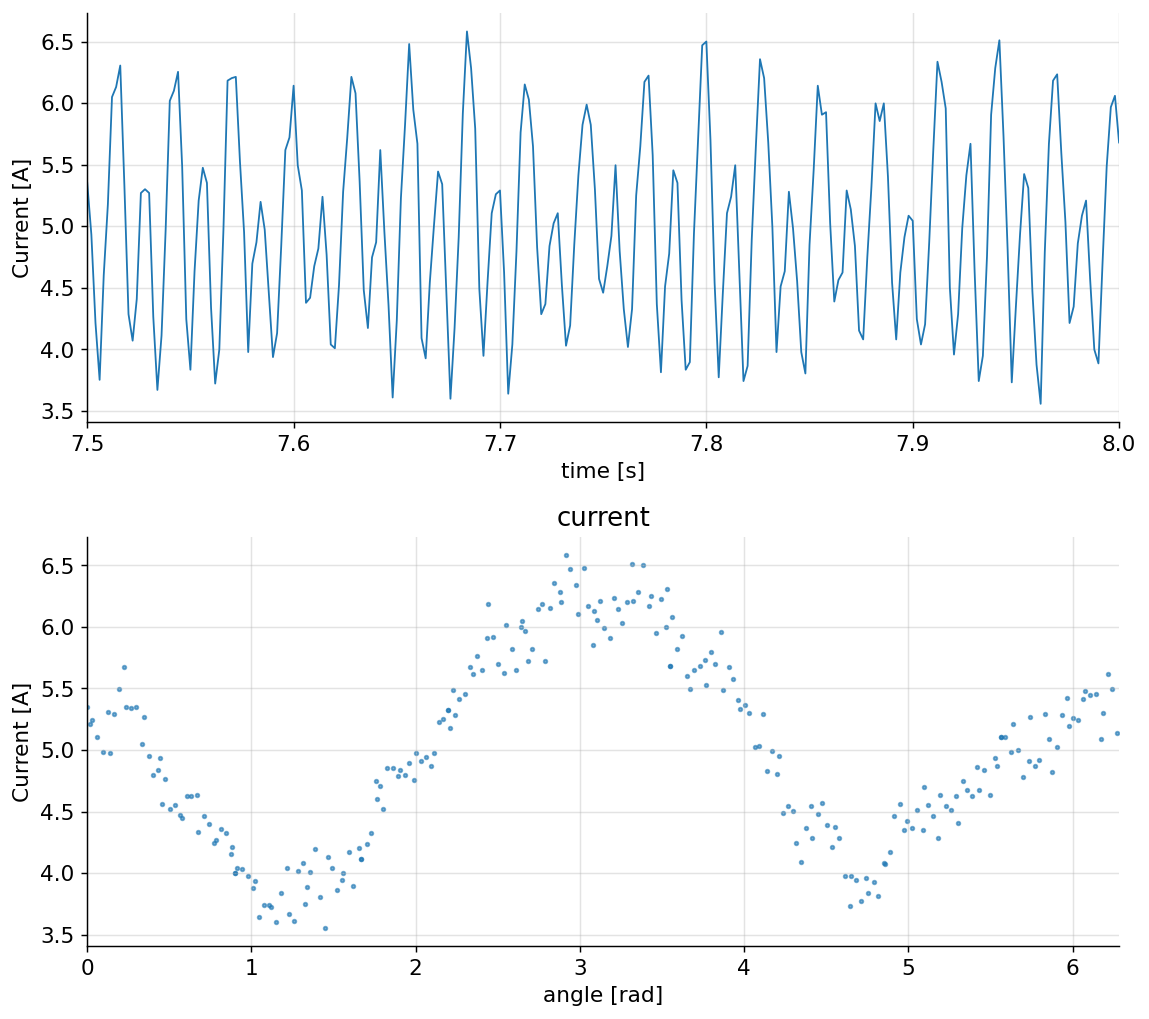

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8))

ax1.plot(window["time"], window[signal_col], color="#1f77b4", linewidth=1)
ax1.set_xlabel("time [s]")
ax1.set_ylabel("Current [A]")
ax1.set_xlim(t_start, t_end)

ax2.scatter(phi_wrapped, window[signal_col], color="#1f77b4", s=4, alpha=0.6)
ax2.set_xlabel("angle [rad]")
ax2.set_ylabel("Current [A]")
ax2.set_xlim(0, 2 * np.pi)
ax2.set_title("current")

plt.tight_layout()
plt.savefig("results/current_time_angle_plot.png", dpi=300, bbox_inches="tight")
plt.show()